# BANK LOAN ANALYSIS

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
import plotly.express as px

In [2]:
df=pd.read_excel("financial_loan.xlsx")

In [3]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [ ]:
df.info() #information on the columns and data
df.describe() # gives complete statically defination of the each date and numerical columns
df.dtypes # will give the data types of each columns

#### Total Loan Applications: We need to calculate the total number of loan applications received during a specified period. Additionally, it is essential to monitor the Month-to-Date (MTD) Loan Applications. This means the application from the latest year and the latest month

In [4]:
total_loan_application=df['id'].count()
print("Total Loan Application recieved = ",total_loan_application)

Total Loan Application recieved =  38576


In [5]:
latest_issue_date=df['issue_date'].max()
latest_year=latest_issue_date.year
latest_month=latest_issue_date.month
mtd_data=df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]
mtd_loan_application=mtd_data['id'].count()
print(f" MTD Loan Application ( For {latest_issue_date.strftime('%B %Y')}):{mtd_loan_application}")

 MTD Loan Application ( For December 2021):4314


#### Total Funded Amount: Understanding the total amount of funds disbursed as loans is crucial. We also want to keep an eye on the MTD Total Funded Amount metric.


#### Total Funded Amount in millions

In [6]:
Total_funded_amount=df['loan_amount'].sum()
Total_funded_amount_in_Millions=Total_funded_amount/1000000
print("Total funded amount is {:.2f} millions dollars".format(Total_funded_amount_in_Millions))

Total funded amount is 435.76 millions dollars


#### MTD-Total Funded Amount in millions

In [7]:
latest_issue_date=df['issue_date'].max()
latest_year=latest_issue_date.year
latest_month=latest_issue_date.month
mtd_data=df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]
mtd_funded_amount=mtd_data['loan_amount'].sum()
mtd_funded_amount_in_millions=mtd_funded_amount/1000000
print("Total MTD funded amount is {:.2f} million dollars".format(mtd_funded_amount_in_millions))

Total MTD funded amount is 53.98 million dollars


#### Total Amount Received: Tracking the total amount received from borrowers is essential for assessing the bank's cash flow and loan repayment. We should analyse the Month-to-Date (MTD) Total Amount Receive.

#### Total Amount Received:

In [8]:
Total_Amount_Recieved=df['total_payment'].sum()
Total_Amount_Recieved_in_Millions=Total_Amount_Recieved/1000000
print("Total Amount Recieved is {:.2f} Million Dollars".format(Total_Amount_Recieved_in_Millions))

Total Amount Recieved is 473.07 Million Dollars


In [9]:
latest_issue_date=df['issue_date'].max()
latest_year=latest_issue_date.year
latest_month=latest_issue_date.month
mtd_data=df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]
mtd_recieved_amount=mtd_data['total_payment'].sum()
mtd_recieved_amount_in_Million=mtd_recieved_amount/1000000
print("Total Recieved Amount is {:.2f} Million Dollars".format(mtd_recieved_amount_in_Million))

Total Recieved Amount is 58.07 Million Dollars


#### Average Interest Rate: Calculating the average interest rate across all loans which will provide insights into our lending portfolio's overall cost.

In [10]:
Average_interest_rate=df['int_rate'].mean()*100
print("Average Intrest Rate across all Loans is {:.2f} %".format(Average_interest_rate))

Average Intrest Rate across all Loans is 12.05 %


#### Average Debt-to-Income Ratio (DTI): Evaluating the average DTI for our borrowers helps us gauge their financial health. We need to compute the average DTI for all loans.

In [11]:
Average_DTI=df['dti'].mean()*100
print("Average DTI For All Loans : {:.2f} %".format(Average_DTI))

Average DTI For All Loans : 13.33 %


### Good Loans Metrics

In [12]:
Good_loan=df[(df['loan_status'].isin(['Fully Paid','Current']))]
Total_Loan_Application=df['id'].count()
Total_Good_Loan=Good_loan['id'].count()
Good_Loan_Funded_Amount=Good_loan['loan_amount'].sum()
Good_Loan_Funded_Amount_in_Millions=Good_Loan_Funded_Amount/1000000
Good_Loan_Recieved_Amount=Good_loan['total_payment'].sum()
Good_Loan_Recieved_Amount_in_Millions=Good_Loan_Recieved_Amount/1000000
Good_Loan_Application_Percent=Total_Good_Loan/Total_Loan_Application*100
print("Total Good Loans are :",Total_Good_Loan)
print("Total Good Loans Funded Amount is {:.2f} Million Dollars".format(Good_Loan_Funded_Amount_in_Millions))
print("Total Good Loans Recieved Amount is {:.2f} Million Doallars".format(Good_Loan_Recieved_Amount_in_Millions))
print("Good Loans Application percentage is {:.2f} %".format(Good_Loan_Application_Percent))

Total Good Loans are : 33243
Total Good Loans Funded Amount is 370.22 Million Dollars
Total Good Loans Recieved Amount is 435.79 Million Doallars
Good Loans Application percentage is 86.18 %


### Bad Loans Metrics

In [13]:
Bad_loan=df[(df['loan_status'].isin(['Charged Off']))]
Total_Loan_Application=df['id'].count()
Total_Bad_Loan=Bad_loan['id'].count()
Bad_Loan_Funded_Amount=Bad_loan['loan_amount'].sum()
Bad_Loan_Funded_Amount_in_Millions=Bad_Loan_Funded_Amount/1000000
Bad_Loan_Recieved_Amount=Bad_loan['total_payment'].sum()
Bad_Loan_Recieved_Amount_in_Millions=Bad_Loan_Recieved_Amount/1000000
Bad_Loan_Application_Percent=Total_Bad_Loan/Total_Loan_Application*100
print("Total Bad Loans are :",Total_Bad_Loan)
print("Total Bad Loans Funded Amount is {:.2f} Million Dollars".format(Bad_Loan_Funded_Amount_in_Millions))
print("Total Bad Loans Recieved Amount is {:.2f} Million Doallars".format(Bad_Loan_Recieved_Amount_in_Millions))
print("Bad Loans Application percentage is {:.2f} %".format(Bad_Loan_Application_Percent))

Total Bad Loans are : 5333
Total Bad Loans Funded Amount is 65.53 Million Dollars
Total Bad Loans Recieved Amount is 37.28 Million Doallars
Bad Loans Application percentage is 13.82 %


#### Monthly Trends by Issue Date on (Total Funded Amount)

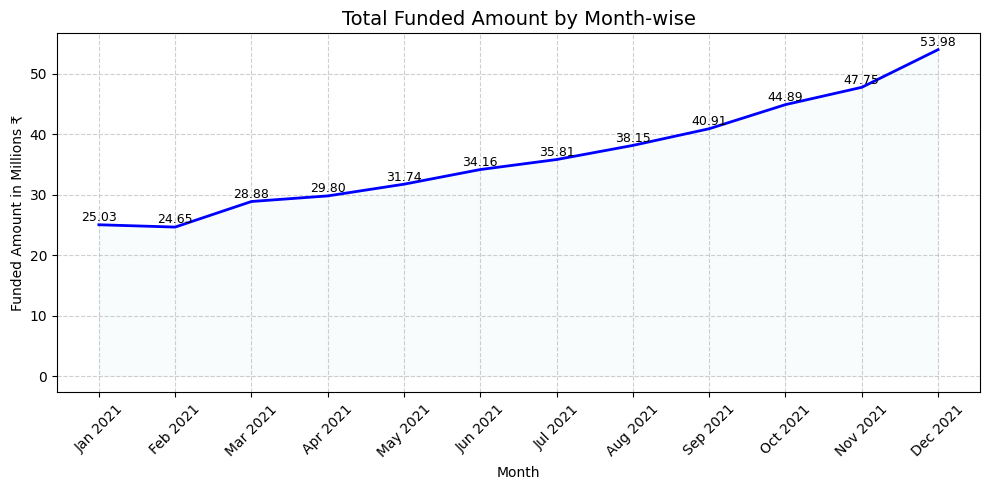

In [14]:
Monthly_Funded=(
    df.sort_values('issue_date')
    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name',sort=False)['loan_amount']
    .sum()
    .div(1000000)
    .reset_index(name='loan_amount_millions')
)
plt.figure(figsize=(10,5))
plt.fill_between(Monthly_Funded['month_name'],Monthly_Funded['loan_amount_millions'],color='skyblue',alpha=0.05)
plt.plot(Monthly_Funded['month_name'],Monthly_Funded['loan_amount_millions'],color='blue',linewidth=2)
for i, row in Monthly_Funded.iterrows():
    plt.text(i, row['loan_amount_millions'] + 0.1,f"{row['loan_amount_millions']:.2f}",
             ha='center', va='bottom',fontsize=9, rotation=0,color='black')
plt.title("Total Funded Amount by Month-wise", fontsize=14)
plt.xlabel('Month')
plt.ylabel('Funded Amount in Millions ₹')
plt.xticks(ticks=range(len(Monthly_Funded)), labels=Monthly_Funded['month_name'],rotation=45)
plt.grid(True,linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()

#### Monthly Trends by Issue Date on (Total Received Amount)

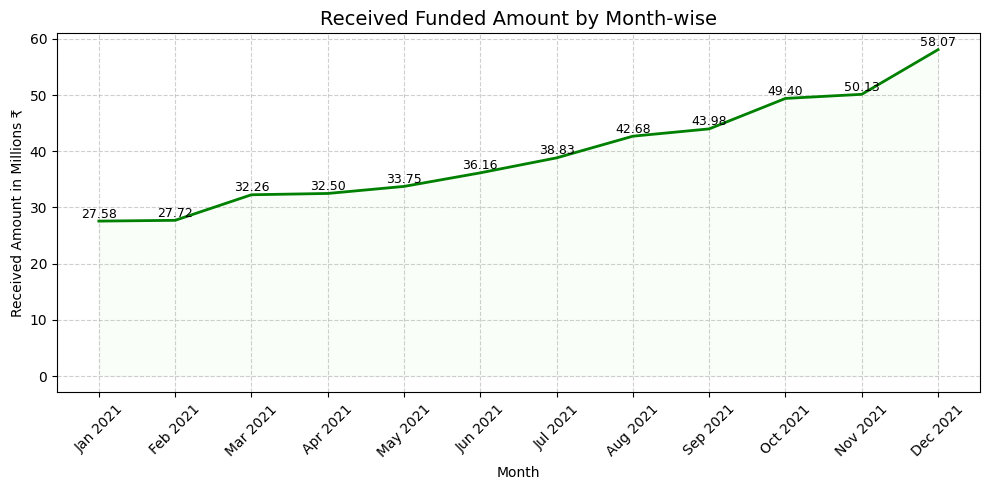

In [15]:
Monthly_Received=(
    df.sort_values('issue_date')
    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name',sort=False)['total_payment']
    .sum()
    .div(1000000)
    .reset_index(name='Received_amount_millions')
)
plt.figure(figsize=(10,5))
plt.fill_between(Monthly_Received['month_name'],Monthly_Received['Received_amount_millions'],color='lightgreen',alpha=0.05)
plt.plot(Monthly_Received['month_name'],Monthly_Received['Received_amount_millions'],color='green',linewidth=2)
for i, row in Monthly_Received.iterrows():
    plt.text(i, row['Received_amount_millions'] + 0.1,f"{row['Received_amount_millions']:.2f}",
             ha='center', va='bottom',fontsize=9, rotation=0,color='black')
plt.title("Received Funded Amount by Month-wise", fontsize=14)
plt.xlabel('Month')
plt.ylabel('Received Amount in Millions ₹')
plt.xticks(ticks=range(len(Monthly_Received)), labels=Monthly_Received['month_name'],rotation=45)
plt.grid(True,linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()

#### Monthly Trends by Issue Date on (Total Loan Application)

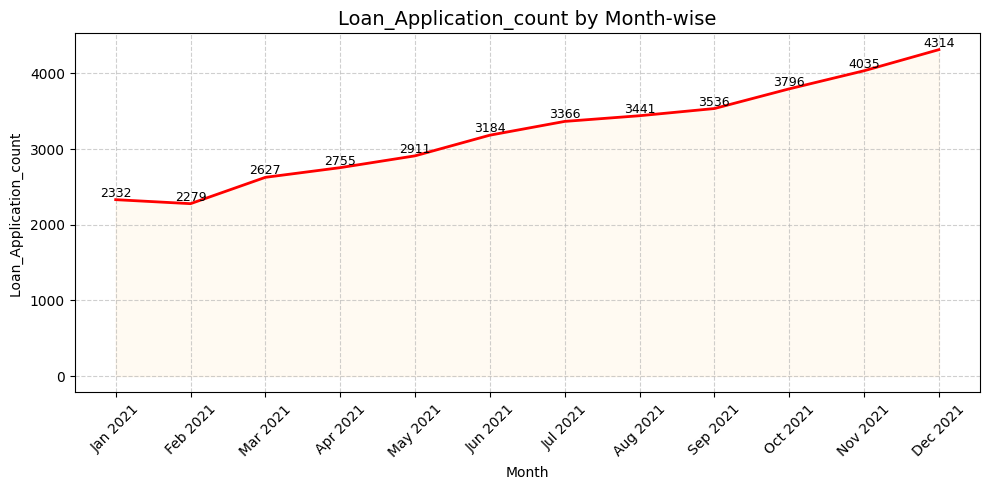

In [16]:
Monthly_Application_Received=(
    df.sort_values('issue_date')
    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name',sort=False)['id']
    .count()
    .reset_index(name='Loan_Application_count')
)
plt.figure(figsize=(10,5))
plt.fill_between(Monthly_Application_Received['month_name'],Monthly_Application_Received['Loan_Application_count'],color='orange',alpha=0.05)
plt.plot(Monthly_Application_Received['month_name'],Monthly_Application_Received['Loan_Application_count'],color='red',linewidth=2)
for i, row in Monthly_Application_Received.iterrows():
    plt.text(i, row['Loan_Application_count'] + 0.1,f"{row['Loan_Application_count']}",
             ha='center', va='bottom',fontsize=9, rotation=0,color='black')
plt.title("Loan_Application_count by Month-wise", fontsize=14)
plt.xlabel('Month')
plt.ylabel('Loan_Application_count ')
plt.xticks(ticks=range(len(Monthly_Application_Received)), labels=Monthly_Application_Received['month_name'],rotation=45)
plt.grid(True,linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()

#### Monthly Trends by Issue Date on (Total Loan Application)

### Regional Analysis of State by total funded Amount

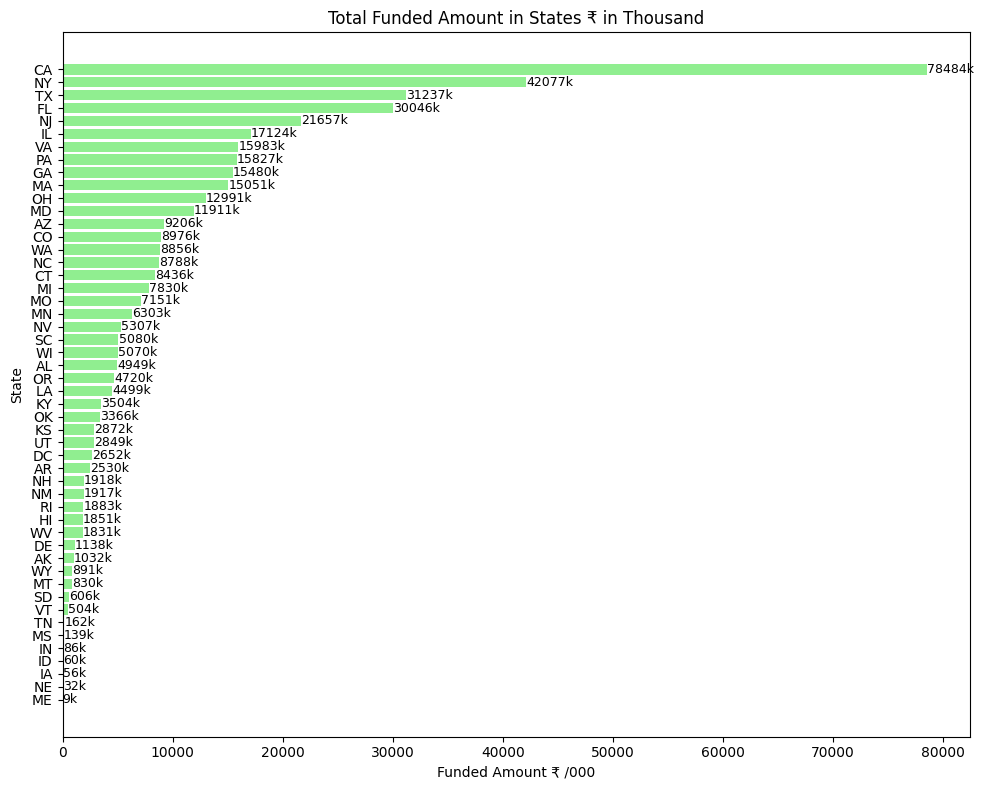

In [17]:
regional_funded_amount=df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
regional_funded_amount_in_thousand=regional_funded_amount/1000
plt.figure(figsize=(10,8))
bars=plt.barh(regional_funded_amount_in_thousand.index,regional_funded_amount_in_thousand.values,color='lightgreen')
for bar in bars:
    width=bar.get_width()
    plt.text(width + 10,bar.get_y() + bar.get_height() /2,
        f'{width:.0f}k',va='center',fontsize=9)
plt.title('Total Funded Amount in States ₹ in Thousand')
plt.xlabel('Funded Amount ₹ /000')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Regional Analysis of State by Total Payment Amount

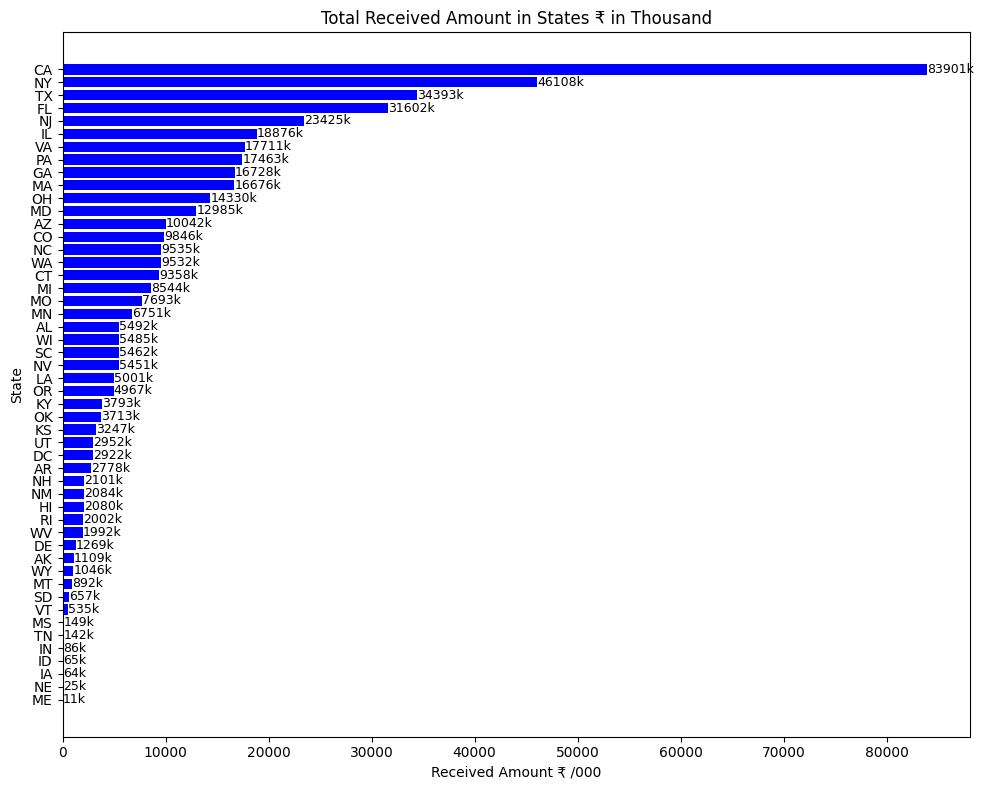

In [18]:
regional_received_amount=df.groupby('address_state')['total_payment'].sum().sort_values(ascending=True)
regional_received_amount_in_thousand=regional_received_amount/1000
plt.figure(figsize=(10,8))
bars=plt.barh(regional_received_amount_in_thousand.index,regional_received_amount_in_thousand.values,color='blue')
for bar in bars:
    width=bar.get_width()
    plt.text(width + 10,bar.get_y() + bar.get_height() /2,
        f'{width:.0f}k',va='center',fontsize=9)
plt.title('Total Received Amount in States ₹ in Thousand')
plt.xlabel('Received Amount ₹ /000')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Regional Analysis of State by Total Loan Application 

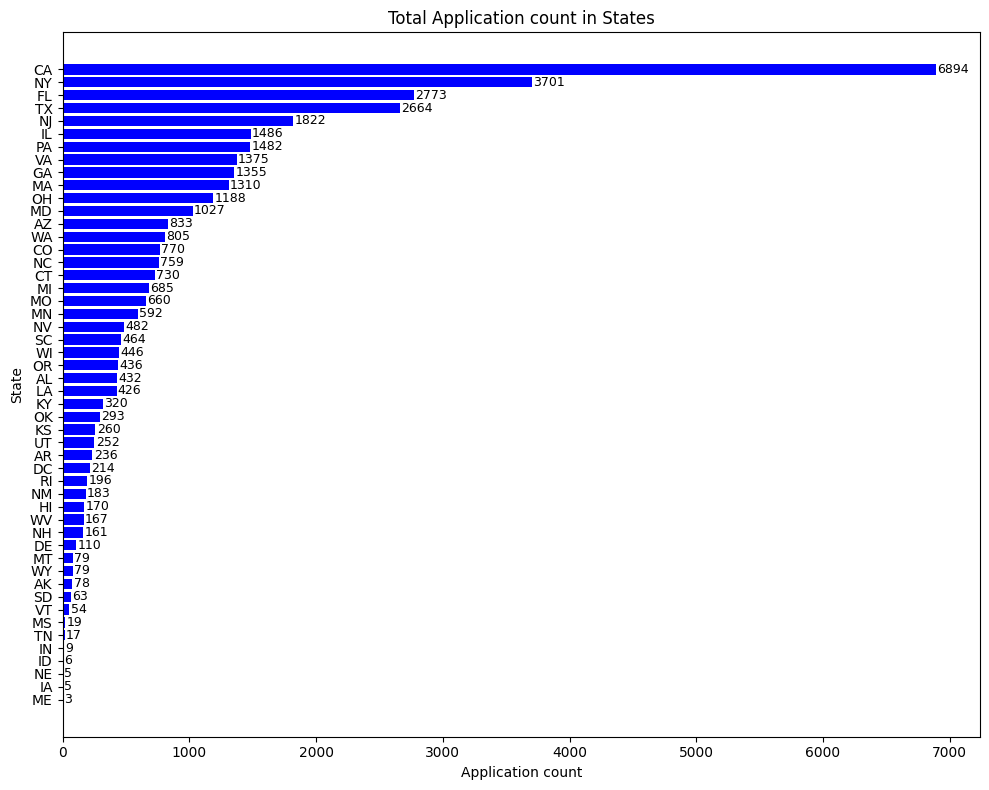

In [19]:
regional_loan_application=df.groupby('address_state')['id'].count().sort_values(ascending=True)
#regional_received_amount_in_thousand=regional_received_amount/1000
plt.figure(figsize=(10,8))
bars=plt.barh(regional_loan_application.index,regional_loan_application.values,color='blue')
for bar in bars:
    width=bar.get_width()
    plt.text(width + 10,bar.get_y() + bar.get_height() /2,
       f'{width:}',va='center',fontsize=9)
plt.title('Total Application count in States')
plt.xlabel('Application count')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Loan Term Analysis As Per Total Funded Amount

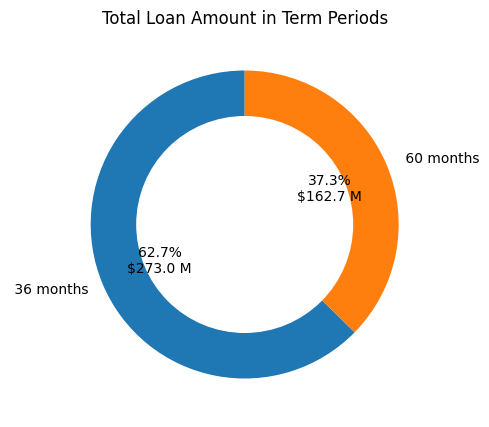

In [20]:
Term_Loan_amount=df.groupby('term')['loan_amount'].sum()/1000000
plt.figure(figsize=(5,5))
plt.pie(
    Term_Loan_amount,
    labels=Term_Loan_amount.index,
    autopct=lambda p: f"{p:.1f}%\n${p*sum(Term_Loan_amount)/100:.1f} M",
    startangle=90,
    wedgeprops={'width':0.4}    
)
plt.gca().add_artist(plt.Circle((0,0),0.70,color='white'))
plt.title('Total Loan Amount in Term Periods')
plt.show()

### Loan Term Analysis As Per Total Received Amount

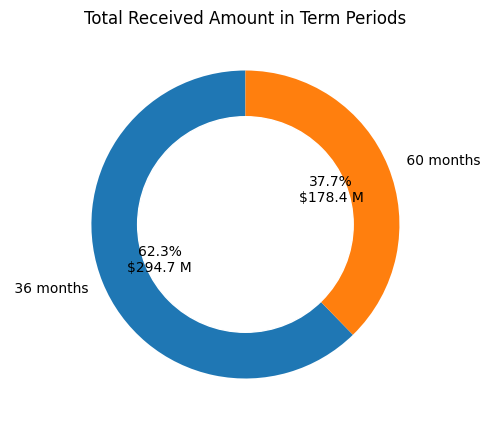

In [21]:
Term_Received_amount=df.groupby('term')['total_payment'].sum()/1000000
plt.figure(figsize=(5,5))
plt.pie(
    Term_Received_amount,
    labels=Term_Received_amount.index,
    autopct=lambda p: f"{p:.1f}%\n${p*sum(Term_Received_amount)/100:.1f} M",
    startangle=90,
    wedgeprops={'width':0.4}
)
plt.gca().add_artist(plt.Circle((0,0),0.70,color='white'))
plt.title('Total Received Amount in Term Periods')
plt.show()

### Loan Term Analysis As Per Loan Application

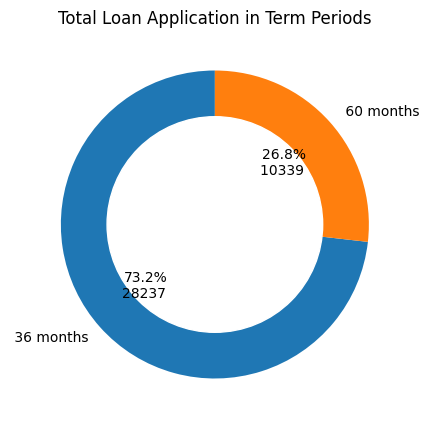

In [22]:
Loan_application_termly=df.groupby('term')['id'].count()
plt.figure(figsize=(5,5))
plt.pie(
    Loan_application_termly,
    labels=Loan_application_termly.index,
    autopct=lambda p: f"{p:.1f}%\n{p*sum(Loan_application_termly)/100:.0f} ",
    startangle=90,
    wedgeprops={'width':0.4}
)
plt.gca().add_artist(plt.Circle((0,0),0.70,color='white'))
plt.title('Total Loan Application in Term Periods')
plt.show()

### Employee Length Analysis based on Total Funded Amount

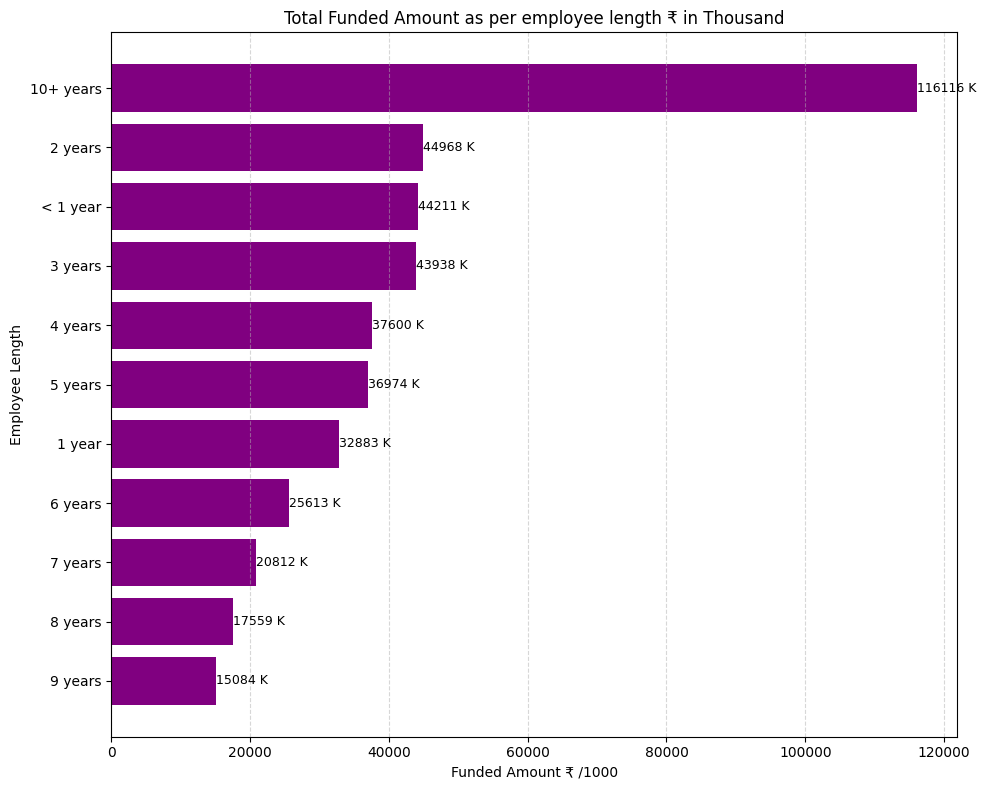

In [34]:
Employee_length_funded_amount=df.groupby('emp_length')['loan_amount'].sum().sort_values(ascending=True)
Employee_length_funded_amount_in_thousand=Employee_length_funded_amount/1000
plt.figure(figsize=(10,8))
bars=plt.barh(Employee_length_funded_amount_in_thousand.index,Employee_length_funded_amount_in_thousand.values,color='purple')
for bar in bars:
    width=bar.get_width()
    plt.text(width + 5,bar.get_y() + bar.get_height() /2,
        f'{width:.0f} K',va='center',fontsize=9)
plt.title('Total Funded Amount as per employee length ₹ in Thousand')
plt.xlabel('Funded Amount ₹ /1000')
plt.ylabel('Employee Length')
plt.grid(axis='x', linestyle ='--',alpha=0.5)
plt.tight_layout()
plt.show()

### Employee Length Analysis based on Total Received Amount

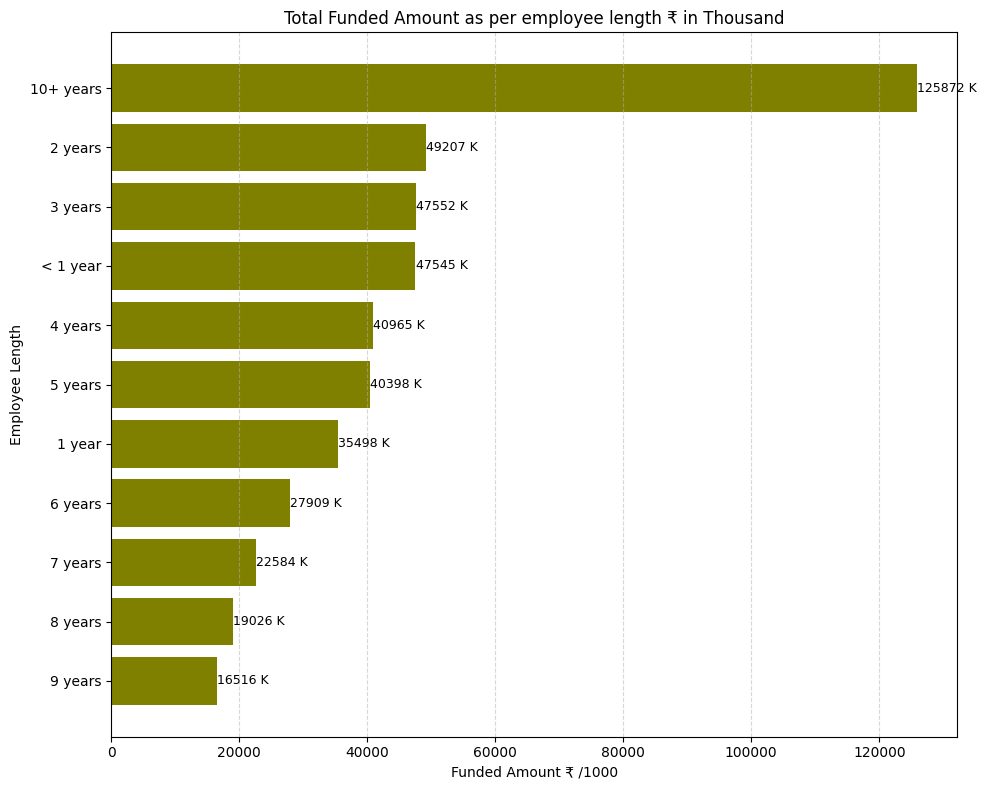

In [36]:
Employee_length_received_amount=df.groupby('emp_length')['total_payment'].sum().sort_values(ascending=True)
Employee_length_received_amount_in_thousand=Employee_length_received_amount/1000
plt.figure(figsize=(10,8))
bars=plt.barh(Employee_length_received_amount_in_thousand.index,Employee_length_received_amount_in_thousand.values,color='olive')
for bar in bars:
    width=bar.get_width()
    plt.text(width + 5,bar.get_y() + bar.get_height() /2,
        f'{width:.0f} K',va='center',fontsize=9)
plt.title('Total Funded Amount as per employee length ₹ in Thousand')
plt.xlabel('Funded Amount ₹ /1000')
plt.ylabel('Employee Length')
plt.grid(axis='x', linestyle ='--',alpha=0.5)
plt.tight_layout()
plt.show()

### Employee Length Analysis based on Loan Application

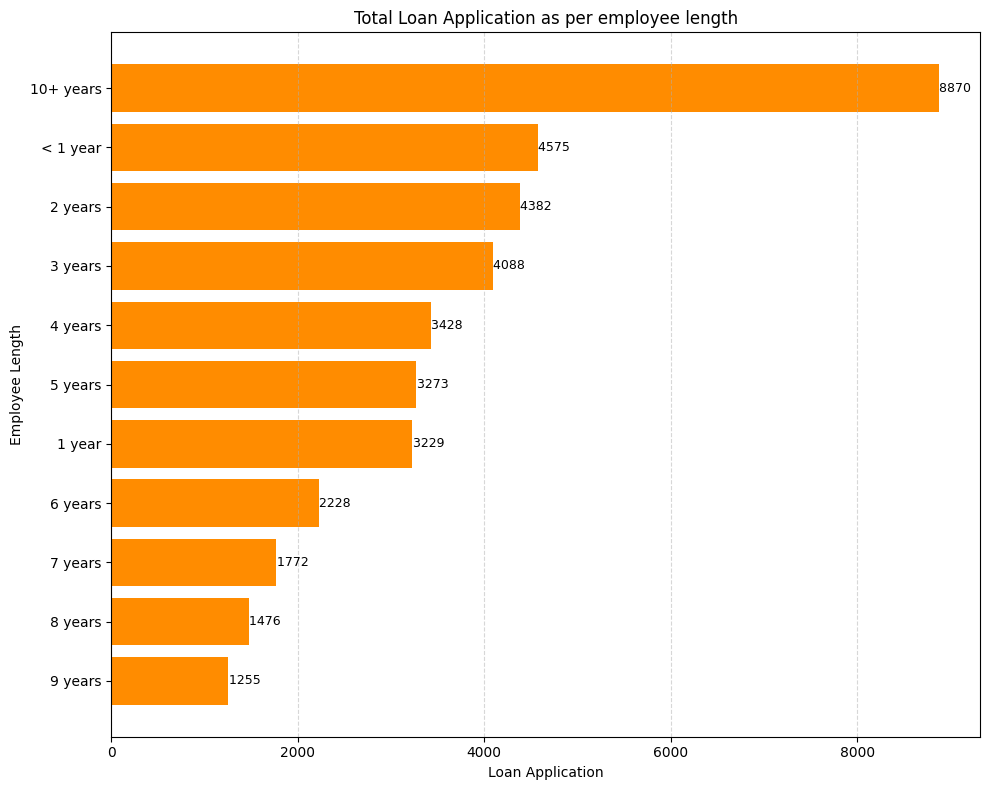

In [37]:
Employee_length_loan_application=df.groupby('emp_length')['id'].count().sort_values(ascending=True)
plt.figure(figsize=(10,8))
bars=plt.barh(Employee_length_loan_application.index,Employee_length_loan_application.values,color='darkorange')
for bar in bars:
    width=bar.get_width()
    plt.text(width + 5,bar.get_y() + bar.get_height() /2,
        f'{width:.0f} ',va='center',fontsize=9)
plt.title('Total Loan Application as per employee length')
plt.xlabel('Loan Application')
plt.ylabel('Employee Length')
plt.grid(axis='x', linestyle ='--',alpha=0.5)
plt.tight_layout()
plt.show()

### Loan Purpose Breakdown as Per Funded Amount

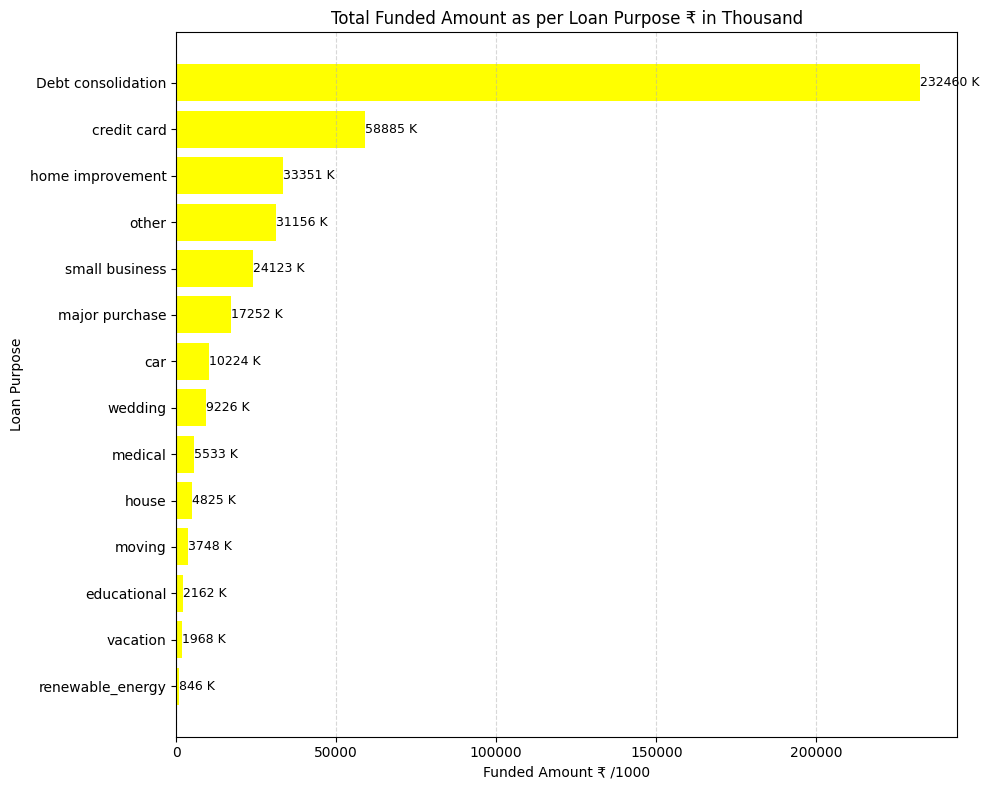

In [40]:
Loan_Purpose_funded_amount=df.groupby('purpose')['loan_amount'].sum().sort_values(ascending=True)
Loan_Purpose_funded_amount_in_thousand=Loan_Purpose_funded_amount/1000
plt.figure(figsize=(10,8))
bars=plt.barh(Loan_Purpose_funded_amount_in_thousand.index,Loan_Purpose_funded_amount_in_thousand.values,color='yellow')
for bar in bars:
    width=bar.get_width()
    plt.text(width + 5,bar.get_y() + bar.get_height() /2,
        f'{width:.0f} K',va='center',fontsize=9)
plt.title('Total Funded Amount as per Loan Purpose ₹ in Thousand')
plt.xlabel('Funded Amount ₹ /1000')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle ='--',alpha=0.5)
plt.tight_layout()
plt.show()

### Loan Purpose Breakdown as Per Received Amount

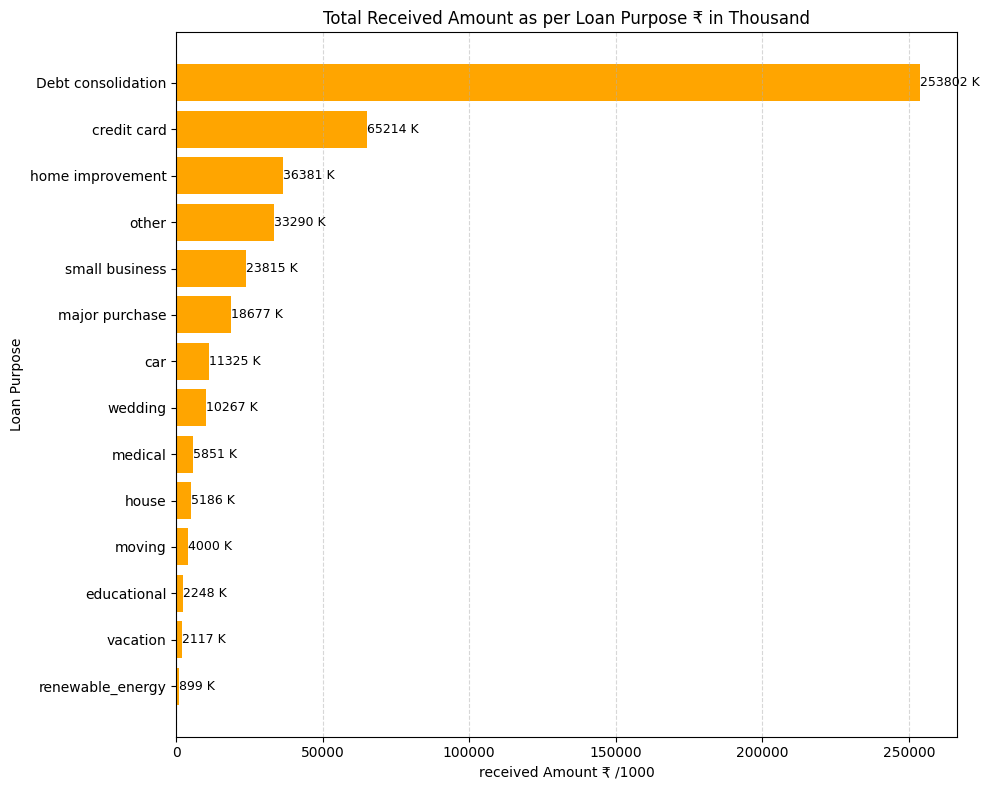

In [41]:
Loan_Purpose_received_amount=df.groupby('purpose')['total_payment'].sum().sort_values(ascending=True)
Loan_Purpose_received_amount_in_thousand=Loan_Purpose_received_amount/1000
plt.figure(figsize=(10,8))
bars=plt.barh(Loan_Purpose_received_amount_in_thousand.index,Loan_Purpose_received_amount_in_thousand.values,color='orange')
for bar in bars:
    width=bar.get_width()
    plt.text(width + 5,bar.get_y() + bar.get_height() /2,
        f'{width:.0f} K',va='center',fontsize=9)
plt.title('Total Received Amount as per Loan Purpose ₹ in Thousand')
plt.xlabel('received Amount ₹ /1000')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle ='--',alpha=0.5)
plt.tight_layout()
plt.show()

### Loan Purpose Breakdown as Per Loan Application

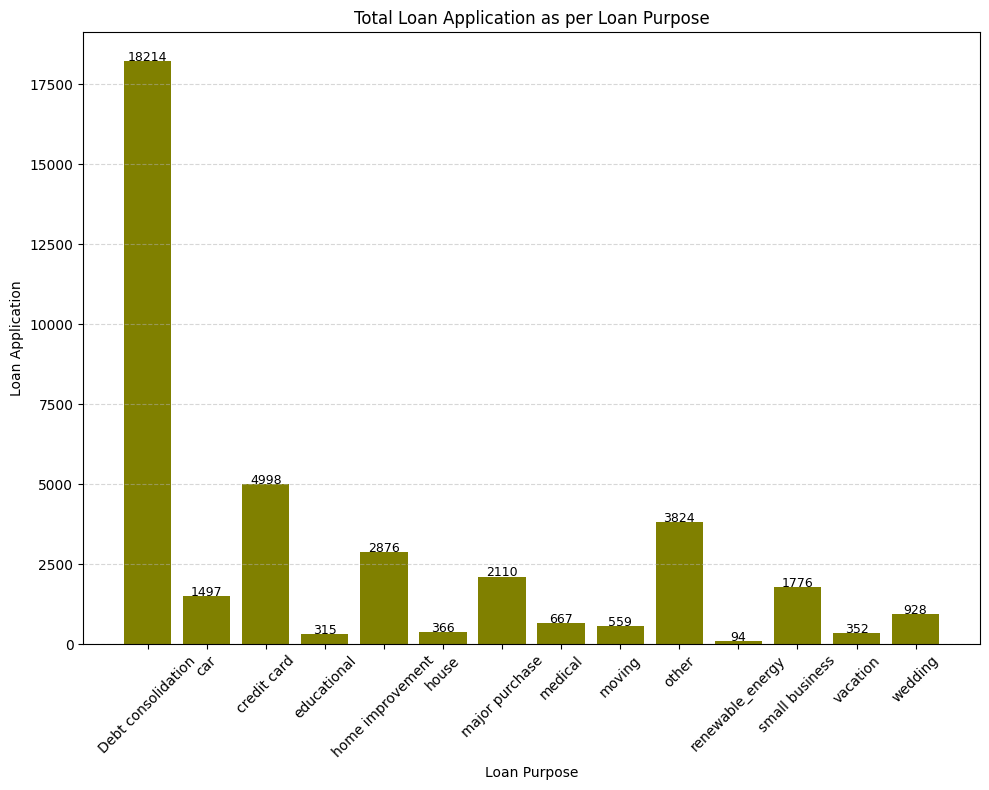

In [61]:
Loan_purpose_loan_application=df.groupby('purpose')['id'].count()
plt.figure(figsize=(10,8))
bars=plt.bar(Loan_purpose_loan_application.index,Loan_purpose_loan_application.values,color='olive')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, height + 5,f'{height:.0f}',
        ha='center',fontsize=9
    )
plt.title('Total Loan Application as per Loan Purpose')
plt.xlabel('Loan Purpose')
plt.ylabel('Loan Application')
plt.grid(axis='y', linestyle ='--',alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Home Ownership Analysis As Per Amaount Funded

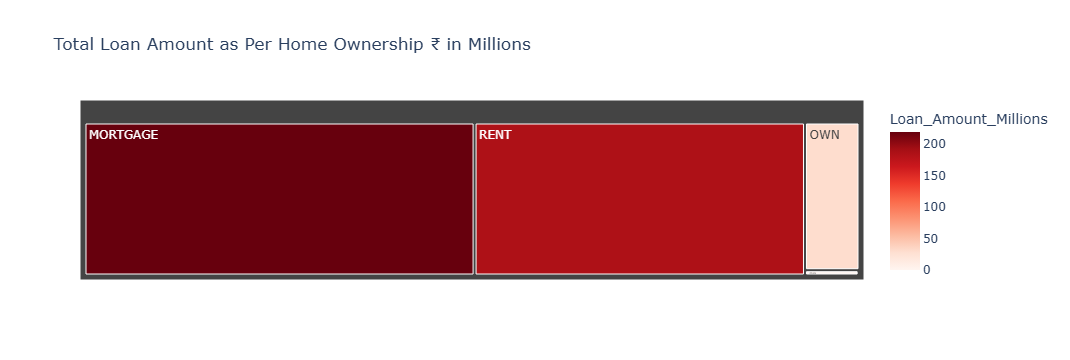

In [70]:
Home_Funded=df.groupby('home_ownership')['loan_amount'].sum().reset_index()
Home_Funded['Loan_Amount_Millions']=Home_Funded['loan_amount']/1000000
fig=px.treemap(
    Home_Funded,
    path=['home_ownership'],
    values='Loan_Amount_Millions',
    color='Loan_Amount_Millions',
    color_continuous_scale='Reds',
    title=('Total Loan Amount as Per Home Ownership ₹ in Millions')
)
fig.show()

In [35]:
df.columns

Index(['id', 'address_state', 'application_type', 'emp_length', 'emp_title',
       'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'next_payment_date', 'member_id',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income',
       'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc',
       'total_payment'],
      dtype='str')

### Home Ownership Analysis As Per Amount Paid

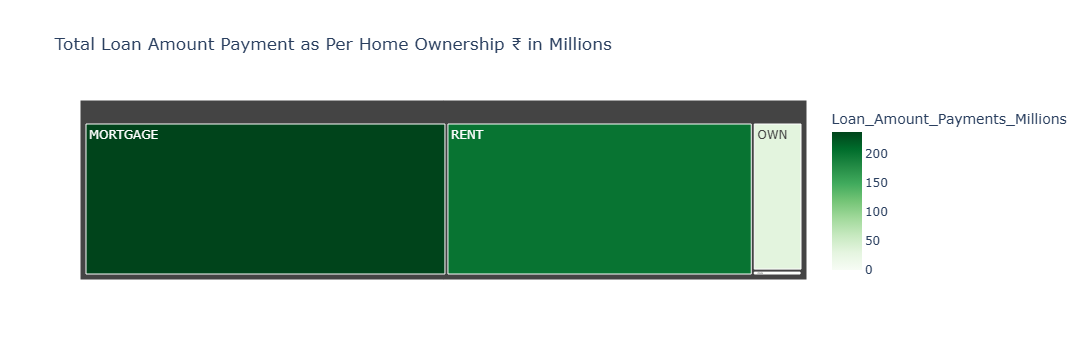

In [72]:
Home_Amount_Payment=df.groupby('home_ownership')['total_payment'].sum().reset_index()
Home_Amount_Payment['Loan_Amount_Payments_Millions']=Home_Amount_Payment['total_payment']/1000000
fig=px.treemap(
    Home_Amount_Payment,
    path=['home_ownership'],
    values='Loan_Amount_Payments_Millions',
    color='Loan_Amount_Payments_Millions',
    color_continuous_scale='Greens',
    title=('Total Loan Amount Payment as Per Home Ownership ₹ in Millions')
)
fig.show()

### Home Ownership Analysis As Per Loan Applications

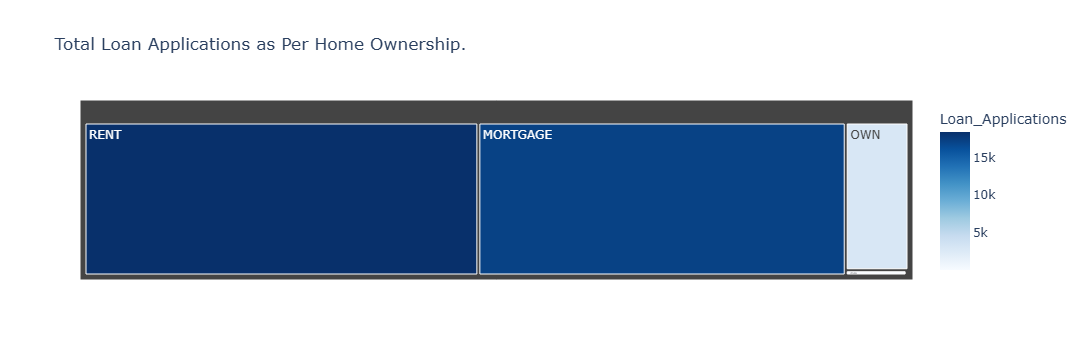

In [79]:
Home_Loan_Applications=df.groupby('home_ownership')['id'].count().reset_index()
Home_Loan_Applications['Loan_Applications']=Home_Loan_Applications['id']
fig=px.treemap(
    Home_Loan_Applications,
    path=['home_ownership'],
    values='Loan_Applications',
    color='Loan_Applications',
    color_continuous_scale='Blues',
    title=('Total Loan Applications as Per Home Ownership.')
)
fig.show()